In [ ]:
from google.colab import drive
try:
  drive.mount('/content/drive', force_remount=True)
  print("Kết nối thành công với gg drive")
except Exception as e:
  print(f"Đã xảy ra lỗi: {e}")

import os
import pandas as pd
import numpy as np
import joblib
import warnings
import time
import psutil
from datetime import datetime
import json

# Nhập các thư viện để lấy phiên bản
import sklearn
import librosa

# Thư viện cho Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Thư viện để vẽ biểu đồ và progress bar
import matplotlib.pyplot as plt
from tqdm import tqdm
# --- CẤU HÌNH CHÍNH ---


Mounted at /content/drive
Kết nối thành công với gg drive


In [ ]:

# 1. Thiết lập thư mục và tên file
OUTPUT_DIR = '/content/drive/MyDrive/HK1-20252026/ClassifyStego'


COVER_FOLDER = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq'
STEGO_FOLDER = '/content/drive/MyDrive/HK1-20252026/ClassifyStego/data_model/phase/Stego'


# Tạo thư mục output nếu chưa tồn tại
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Các tên file cố định
FEATURES_FILE = os.path.join(OUTPUT_DIR, 'data_processed','phase_features.npz')
MODEL_FILE_SVM = os.path.join(OUTPUT_DIR, 'Phase','SVM', 'best_svm_model.pkl')
MODEL_FILE_RF = os.path.join(OUTPUT_DIR, 'Phase','RandomForest', 'best_rf_model.pkl')
MODEL_FILE_LR = os.path.join(OUTPUT_DIR, 'Phase','LogisticRegression', 'best_lr_model.pkl')
SCALER_FILE = os.path.join(OUTPUT_DIR,'Phase', 'scaler.pkl')

In [ ]:
!pip install tqdm

In [ ]:



# 2. Tạo timestamp cho các file log và report
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")



rpSVM = 'Phase/SVM/reportSVM_' + TIMESTAMP
rpRF = 'Phase/RandomForest/reportRF_' + TIMESTAMP
rpLR = 'Phase/LogisticRegression/reportLR_' + TIMESTAMP

# os.makedirs(os.path.join(OUTPUT_DIR, rpSVM), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, rpRF), exist_ok=True)
# os.makedirs(os.path.join(OUTPUT_DIR, rpLR), exist_ok=True)

JSON_REPORT_FILE_SVM = os.path.join(OUTPUT_DIR,rpSVM, f'report_{TIMESTAMP}.json')
JSON_REPORT_FILE_SVM_DEFAULT = os.path.join(OUTPUT_DIR,rpSVM, f'report_default_{TIMESTAMP}.json')
GRID_SEARCH_LOG_FILE_SVM = os.path.join(OUTPUT_DIR, rpSVM,f'grid_search_log_{TIMESTAMP}.csv')

JSON_REPORT_FILE_RF = os.path.join(OUTPUT_DIR,rpRF, f'report_{TIMESTAMP}.json')
JSON_REPORT_FILE_RF_DEFAULT = os.path.join(OUTPUT_DIR,rpRF, f'report_default_{TIMESTAMP}.json')
GRID_SEARCH_LOG_FILE_RF = os.path.join(OUTPUT_DIR, rpRF,f'grid_search_log_{TIMESTAMP}.csv')

JSON_REPORT_FILE_LR = os.path.join(OUTPUT_DIR,rpLR, f'report_{TIMESTAMP}.json')
JSON_REPORT_FILE_LR_DEFAULT = os.path.join(OUTPUT_DIR,rpLR, f'report_default_{TIMESTAMP}.json')
GRID_SEARCH_LOG_FILE_LR = os.path.join(OUTPUT_DIR, rpLR,f'grid_search_log_{TIMESTAMP}.csv')





In [ ]:
# --- KHỞI TẠO ---
start_time = time.time()
process = psutil.Process(os.getpid())
mem_before = process.memory_info().rss / (1024 * 1024)
log_data = {} # Khởi tạo dictionary để chứa toàn bộ thông tin log
warnings.filterwarnings("ignore", category=FutureWarning)

from scipy.stats import skew, kurtosis
def extract_features(file_path, n_mfcc=80):
    """
    Trích xuất đặc trưng MFCC và các đặc trưng thống kê bậc cao.
    """
    try:
        y, sr = librosa.load(file_path, sr=None, duration=5.0)
        if len(y) < 5 * sr:
            y = np.tile(y, int(np.ceil((5 * sr) / len(y))))
        y = y[:5 * sr]

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_t = mfccs.T

        features = np.hstack([
            np.mean(mfccs_t, axis=0),
            np.std(mfccs_t, axis=0),
            skew(mfccs_t, axis=0),
            kurtosis(mfccs_t, axis=0)
        ])
        return features
    except Exception as e:
        print(f"Lỗi khi xử lý file {file_path}: {e}")
        return None

def load_data_from_audio(cover_folder, stego_folder):
    features, labels, files_to_process = [], [], []
    for root, _, files in os.walk(cover_folder):
        for f in files:
            if f.endswith('.wav'): files_to_process.append({'path': os.path.join(root, f), 'label': 0})
    for root, _, files in os.walk(stego_folder):
        for f in files:
            if f.endswith('.wav'): files_to_process.append({'path': os.path.join(root, f), 'label': 1})

    for file_info in tqdm(files_to_process, desc="Đang xử lý audio"):
        mfccs = extract_features(file_info['path'])
        if mfccs is not None:
            features.append(mfccs); labels.append(file_info['label'])
    return np.array(features), np.array(labels)

# --- TẢI DỮ LIỆU ---
if os.path.exists(FEATURES_FILE):
    print(f" Tải dữ liệu đặc trưng từ file '{FEATURES_FILE}'...")
    data = np.load(FEATURES_FILE); X, y = data['features'], data['labels']
else:
    print(f" Không tìm thấy file đặc trưng. Bắt đầu xử lý audio...")
    X, y = load_data_from_audio(COVER_FOLDER, STEGO_FOLDER)
    print(f"Lưu đặc trưng vào file '{FEATURES_FILE}'...")
    np.savez_compressed(FEATURES_FILE, features=X, labels=y)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
# print(f"Số NaN sau khi xử lý: {np.isnan(X).sum()}")

# Lưu thông tin dataset vào log
log_data['dataset_info'] = {
    'total_samples': X.shape[0],
    'num_features': X.shape[1],
    'class_distribution': {
        'cover_0': int(np.sum(y == 0)),
        'stego_1': int(np.sum(y == 1))
    }
}

print(f"\nTổng cộng {X.shape[0]} mẫu dữ liệu sẵn sàng.")



# Bước 1: Chia dữ liệu TRƯỚC KHI chuẩn hóa
# Chúng ta sẽ chia dữ liệu thô (X)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Đã chia dữ liệu thành {len(X_train_raw)} mẫu train và {len(X_test_raw)} mẫu test.")

# Bước 2: Khởi tạo và Fit Scaler CHỈ trên tập huấn luyện
scaler = StandardScaler()
print("Đang fit scaler CHỈ trên dữ liệu train...")
scaler.fit(X_train_raw)

# Bước 3: Áp dụng phép biến đổi (transform) cho cả hai tập
print("Đang transform cả hai tập train và test...")
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Bước 4: Lưu scaler đã được huấn luyện đúng cách
print("Đang lưu scaler...")
joblib.dump(scaler, SCALER_FILE)

print("Hoàn tất quá trình chuẩn hóa dữ liệu một cách an toàn.")
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")

 Tải dữ liệu đặc trưng từ file '/content/drive/MyDrive/HK1-20252026/ClassifyStego/data_processed/phase_features.npz'...

Tổng cộng 1445 mẫu dữ liệu sẵn sàng.
Đã chia dữ liệu thành 1156 mẫu train và 289 mẫu test.
Đang fit scaler CHỈ trên dữ liệu train...
Đang transform cả hai tập train và test...
Đang lưu scaler...
Hoàn tất quá trình chuẩn hóa dữ liệu một cách an toàn.
Kích thước tập huấn luyện: (1156, 320)
Kích thước tập kiểm thử: (289, 320)


In [ ]:


def run_default_experiment(model_name, estimator, report_file, X_train, y_train, X_test, y_test):
    print("\n" + "="*60)
    print(f"BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: {model_name.upper()}")
    print("="*60)

    log_data = {}
    process = psutil.Process(os.getpid())

    # --- HUẤN LUYỆN VỚI THAM SỐ MẶC ĐỊNH ---
    print(f"\n⚠️ Huấn luyện mô hình {model_name} với tham số mặc định...")
    mem_before_train = process.memory_info().rss
    start_time_train = time.time()

    estimator.fit(X_train, y_train)

    training_duration = time.time() - start_time_train
    mem_after_train = process.memory_info().rss
    training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)
    print(f"Huấn luyện hoàn tất sau {training_duration:.2f} giây.")

    log_data['training_info'] = {
        'status': 'Trained with default parameters', 'model_class': type(estimator).__name__,
        'training_duration_seconds': round(training_duration, 2),
        'training_memory_increase_mb': round(training_memory_increase_mb, 2),
        'all_model_params': estimator.get_params() # Đã lưu tất cả tham số mặc định
    }

    # --- ĐÁNH GIÁ HIỆU NĂNG ---
    print(f"\n--- Đánh giá hiệu năng mô hình {model_name} (mặc định) ---")

    start_time_predict = time.time()
    y_test_pred = estimator.predict(X_test)
    prediction_duration = time.time() - start_time_predict

    y_train_pred = estimator.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # --- PHẦN THÊM MỚI ---
    print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Train:")
    print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"\nĐộ chính xác trên tập Test: {test_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Test:")
    print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"Thời gian dự đoán trên tập Test: {prediction_duration:.4f} giây")

    # Vẽ ma trận nhầm lẫn
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover (0)', 'Stego (1)'], cmap=plt.cm.Blues)
    plt.title(f"Ma trận nhầm lẫn trên tập Test ({model_name} - Mặc định)")
    plt.show()
    # -----------------------

    log_data['evaluation_results'] = {
        'train_set': {'accuracy': train_accuracy, 'classification_report': classification_report(y_train, y_train_pred, output_dict=True)},
        'test_set': {'accuracy': test_accuracy, 'classification_report': classification_report(y_test, y_test_pred, output_dict=True)},
        'prediction_duration_seconds': round(prediction_duration, 4)
    }

    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False)
    print(f"📝 Đã lưu báo cáo mặc định chi tiết vào file: {report_file}")



def run_experiment(model_name, estimator, param_grid, model_file, report_file, log_file, X_train, y_train, X_test, y_test, scaler, scaler_file):
    print("\n" + "="*60)
    print(f"BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: {model_name.upper()}")
    print("="*60)

    log_data = {}
    process = psutil.Process(os.getpid())

    if os.path.exists(model_file):
        print(f"\n✅ Đã tìm thấy mô hình. Đang tải từ file '{model_file}'...")
        best_model = joblib.load(model_file)
        log_data['training_info'] = {'status': f'Loaded pre-trained model: {type(best_model).__name__}'}
    else:
        print(f"\n⚠️ Bắt đầu huấn luyện mô hình mới (có tinh chỉnh)...")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        grid_search = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring='accuracy', cv=cv, verbose=2, n_jobs=-1)

        mem_before_train = process.memory_info().rss
        start_time_train = time.time()
        grid_search.fit(X_train, y_train)
        training_duration = time.time() - start_time_train
        mem_after_train = process.memory_info().rss
        training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)

        best_model = grid_search.best_estimator_

        log_data['training_info'] = {
            'status': 'Newly trained model', 'model_class': type(best_model).__name__,
            'best_cv_score': grid_search.best_score_, 'best_params_from_grid': grid_search.best_params_,
            'training_duration_seconds': round(training_duration, 2),
            'training_memory_increase_mb': round(training_memory_increase_mb, 2),
            'all_model_params': best_model.get_params() # <-- ĐÃ CÓ SẴN Ở ĐÂY
        }
        joblib.dump(best_model, model_file)
        pd.DataFrame(grid_search.cv_results_).to_csv(log_file, index=False)
        print(f"Đã lưu mô hình và log GridSearch sau {training_duration:.2f} giây.")

    print(f"\n--- Đánh giá hiệu năng mô hình {model_name} (tinh chỉnh) ---")

    start_time_predict = time.time()
    y_test_pred = best_model.predict(X_test)
    prediction_duration = time.time() - start_time_predict

    y_train_pred = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # --- PHẦN THÊM MỚI ---
    print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Train:")
    print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"\nĐộ chính xác trên tập Test: {test_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Test:")
    print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"Thời gian dự đoán trên tập Test: {prediction_duration:.4f} giây")
    # -----------------------

    # Vẽ ma trận nhầm lẫn
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover (0)', 'Stego (1)'], cmap=plt.cm.Blues)
    plt.title(f"Ma trận nhầm lẫn trên tập Test ({model_name} - Tinh chỉnh)")
    plt.show()

    log_data['evaluation_results'] = {
        'train_set': {'accuracy': train_accuracy, 'classification_report': classification_report(y_train, y_train_pred, output_dict=True)},
        'test_set': {'accuracy': test_accuracy, 'classification_report': classification_report(y_test, y_test_pred, output_dict=True)},
        'prediction_duration_seconds': round(prediction_duration, 4)
    }

    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False)
    print(f"📝 Đã lưu báo cáo tinh chỉnh chi tiết vào file: {report_file}")

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# --- A. Chạy thử nghiệm cho SVM  ---

run_default_experiment('SVM', SVC(probability=True, random_state=42), JSON_REPORT_FILE_SVM_DEFAULT, X_train, y_train, X_test, y_test)

svm_estimator = SVC(probability=True, random_state=42)

# svm_param_grid = {
#     'C': [0.1, 1, 10],
#     'gamma': [ 0.1, 0.01, 0.001],
#     'kernel': ['rbf'],
#     'class_weight': ['balanced']
# }

svm_param_grid = {
    'C': [0.1, 1],
    'gamma': [  0.01, 0.001],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
run_experiment('SVM', svm_estimator, svm_param_grid, MODEL_FILE_SVM, JSON_REPORT_FILE_SVM, GRID_SEARCH_LOG_FILE_SVM, X_train, y_train, X_test, y_test, scaler, SCALER_FILE)




print("\n🎉 Hoàn tất tất cả các thử nghiệm!")


BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: SVM

⚠️ Huấn luyện mô hình SVM với tham số mặc định...


KeyboardInterrupt: 


BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: RANDOMFOREST

⚠️ Huấn luyện mô hình RandomForest với tham số mặc định...
Huấn luyện hoàn tất sau 1.26 giây.

--- Đánh giá hiệu năng mô hình RandomForest (mặc định) ---

Độ chính xác trên tập Train: 0.8772
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.81      1.00      0.89       600
   Stego (1)       1.00      0.74      0.85       556

    accuracy                           0.88      1156
   macro avg       0.90      0.87      0.87      1156
weighted avg       0.90      0.88      0.87      1156


Độ chính xác trên tập Test: 0.7751
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.72      0.92      0.81       150
   Stego (1)       0.88      0.62      0.73       139

    accuracy                           0.78       289
   macro avg       0.80      0.77      0.77       289
weighted avg       0.80      0.78      0.77       289

Thời gi

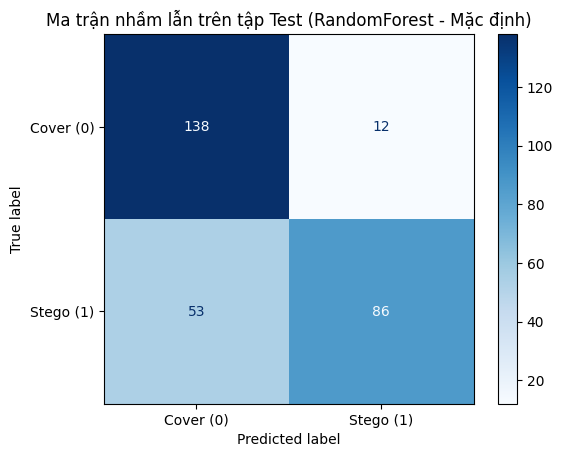

📝 Đã lưu báo cáo mặc định chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/Phase/RandomForest/reportRF_20251105_174011/report_default_20251105_174011.json

BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: RANDOMFOREST

⚠️ Bắt đầu huấn luyện mô hình mới (có tinh chỉnh)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Đã lưu mô hình và log GridSearch sau 151.32 giây.

--- Đánh giá hiệu năng mô hình RandomForest (tinh chỉnh) ---

Độ chính xác trên tập Train: 0.8322
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.76      0.99      0.86       600
   Stego (1)       0.99      0.66      0.79       556

    accuracy                           0.83      1156
   macro avg       0.87      0.83      0.83      1156
weighted avg       0.87      0.83      0.83      1156


Độ chính xác trên tập Test: 0.7716
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.71      

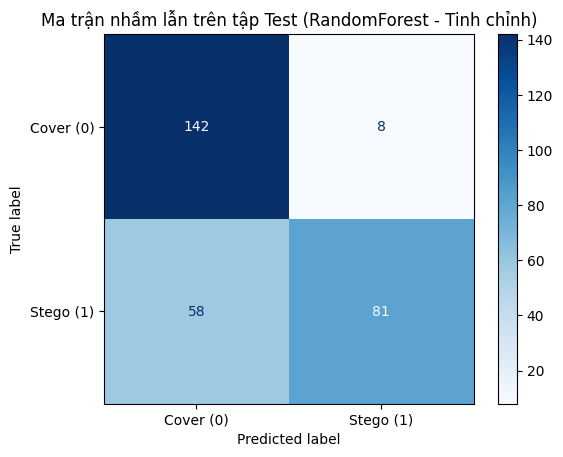

📝 Đã lưu báo cáo tinh chỉnh chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/Phase/RandomForest/reportRF_20251105_174011/report_20251105_174011.json


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# --- B. Chạy thử nghiệm cho Random Forest ---

run_default_experiment('RandomForest', RandomForestClassifier(random_state=42, n_jobs=-1), JSON_REPORT_FILE_RF_DEFAULT, X_train, y_train, X_test, y_test)

rf_estimator = RandomForestClassifier(random_state=42, n_jobs=-1)
# rf_param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [5],
#     'min_samples_split': [10, 20],
#     'min_samples_leaf': [10 ,20],
#     'max_features': ['sqrt', 'log2'],
#     'class_weight': ['balanced']
# }

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [10 ,20],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}
run_experiment('RandomForest', rf_estimator, rf_param_grid, MODEL_FILE_RF, JSON_REPORT_FILE_RF, GRID_SEARCH_LOG_FILE_RF, X_train, y_train, X_test, y_test, scaler, SCALER_FILE)




BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: LOGISTICREGRESSION

⚠️ Huấn luyện mô hình LogisticRegression với tham số mặc định...
Huấn luyện hoàn tất sau 0.12 giây.

--- Đánh giá hiệu năng mô hình LogisticRegression (mặc định) ---

Độ chính xác trên tập Train: 0.8702
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.80      1.00      0.89       600
   Stego (1)       1.00      0.73      0.84       556

    accuracy                           0.87      1156
   macro avg       0.90      0.87      0.87      1156
weighted avg       0.90      0.87      0.87      1156


Độ chính xác trên tập Test: 0.8062
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.74      0.96      0.84       150
   Stego (1)       0.94      0.64      0.76       139

    accuracy                           0.81       289
   macro avg       0.84      0.80      0.80       289
weighted avg       0.84      0.81      0.80 

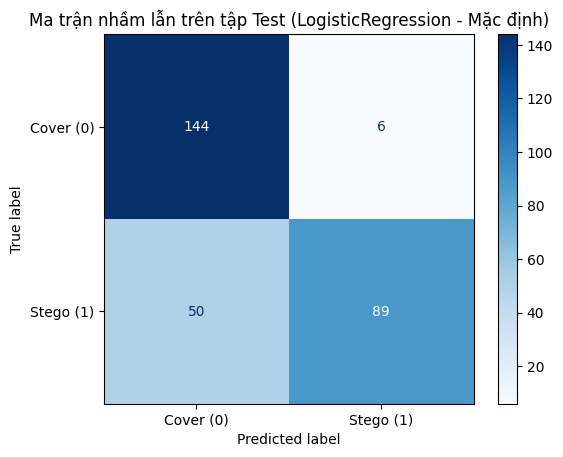

📝 Đã lưu báo cáo mặc định chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/Phase/LogisticRegression/reportLR_20251105_081846/report_default_20251105_081846.json

BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: LOGISTICREGRESSION

⚠️ Bắt đầu huấn luyện mô hình mới (có tinh chỉnh)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Đã lưu mô hình và log GridSearch sau 417.49 giây.

--- Đánh giá hiệu năng mô hình LogisticRegression (tinh chỉnh) ---

Độ chính xác trên tập Train: 0.8599
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.79      0.99      0.88       600
   Stego (1)       0.99      0.72      0.83       556

    accuracy                           0.86      1156
   macro avg       0.89      0.85      0.86      1156
weighted avg       0.89      0.86      0.86      1156


Độ chính xác trên tập Test: 0.8097
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)

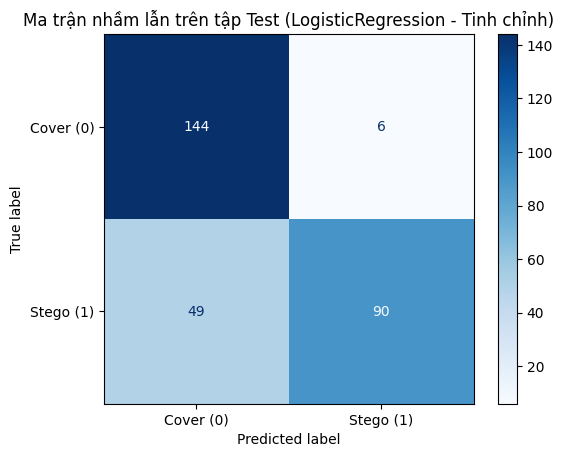

📝 Đã lưu báo cáo tinh chỉnh chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/Phase/LogisticRegression/reportLR_20251105_081846/report_20251105_081846.json


In [ ]:

# --- C. Chạy thử nghiệm cho Logistic Regression  ---

run_default_experiment('LogisticRegression', LogisticRegression(random_state=42, max_iter=2000), JSON_REPORT_FILE_LR_DEFAULT, X_train, y_train, X_test, y_test)

lr_estimator = LogisticRegression(random_state=42, max_iter=5000)
# Thử nghiệm cả 2 loại phạt L1 và L2 với các solver tương ứng
lr_param_grid = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.01, 0.1, 1]
    },
    {
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs', 'saga'],
        'C': [0.01, 0.1, 1, ]
    }
]
run_experiment('LogisticRegression', lr_estimator, lr_param_grid, MODEL_FILE_LR, JSON_REPORT_FILE_LR, GRID_SEARCH_LOG_FILE_LR, X_train, y_train, X_test, y_test, scaler, SCALER_FILE)

In [ ]:
!apt-get update && apt-get install -y ffmpeg

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,372 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,287 kB]
Get:14 http://ar